### Load packages

In [156]:
import pandas as pd
import os
import textwrap
import numpy as np

# for figures
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from pandas.plotting import scatter_matrix

### Set project parameters for this run

In [157]:
# Project parameters

data_directory = r"..\data\unified_csvs"

vct_file = "vct_unified_prepped"
vct_path = os.path.join(data_directory, vct_file + ".csv")
print(vct_path)

..\data\unified_csvs\vct_unified_prepped.csv


### Load algae bloom data

In [158]:
# Load algae bloom data file

vct_raw_df = pd.read_csv(vct_path)

In [159]:
vct_raw_df.iloc[:5, :]
# vct_raw_df.iloc[:10, 10:25]
# vct_raw_df.iloc[:10, 10:25]

,report_date,waterbody,region,site,station,latitude,longitude,cyanotaxa,feature_water_temp,feature_water_surface,feature_anabaena,feature_aphanizomenon,feature_microcystin,feature_oscillatoria,target_bloom_intensity,target_bloom
0,08/01/2022,Lake Champlain,Champlain - South Lake,2.0,LTM 02,43.714009,-73.383001,NaN,76.0,Rolling,0,0,0,0,1b,0
1,08/22/2022,Lake Champlain,Champlain - South Lake,2.0,LTM 02,43.714009,-73.383001,NaN,77.0,Calm,0,0,0,0,1b,0
2,10/05/2022,Lake Champlain,Champlain - South Lake,2.0,LTM 02,43.714009,-73.383001,NaN,57.0,Calm,0,0,0,0,1b,0
3,10/21/2022,Lake Champlain,Champlain - South Lake,2.0,LTM 02,43.714009,-73.383001,NaN,52.0,Rolling,0,0,0,0,1b,0
4,06/23/2022,Lake Champlain,Champlain - Main Lake South,3.0,Arnold Bay,44.149521,-73.367368,NaN,NaN,Rolling,0,0,0,0,1a,0


In [160]:
print(len(vct_raw_df.columns))
vct_raw_df.columns

16


Index(['report_date', 'waterbody', 'region', 'site', 'station', 'latitude',
       'longitude', 'cyanotaxa', 'feature_water_temp', 'feature_water_surface',
       'feature_anabaena', 'feature_aphanizomenon', 'feature_microcystin',
       'feature_oscillatoria', 'target_bloom_intensity', 'target_bloom'],
      dtype='object')

In [161]:
# Convert number columns to floats and integers as appropriate

vct_numcols_df = vct_raw_df.copy()

float_cols = ["feature_water_temp", "feature_anabaena", "feature_aphanizomenon", "feature_microcystin", "feature_oscillatoria", "latitude", "longitude"]
int_cols = ["site", "target_bloom"]

vct_numcols_df[float_cols] = vct_numcols_df[float_cols].apply(pd.to_numeric, errors="coerce")

vct_numcols_df[int_cols] = (vct_numcols_df[int_cols].apply(pd.to_numeric, errors="coerce").astype("Int64"))

vct_numcols_df[["feature_water_temp", "feature_anabaena", "feature_aphanizomenon", "feature_microcystin", "feature_oscillatoria", "latitude", "longitude",
                "site", "target_bloom"]].head()

,feature_water_temp,feature_anabaena,feature_aphanizomenon,feature_microcystin,feature_oscillatoria,latitude,longitude,site,target_bloom
0,76.0,0,0,0,0,43.714009,-73.383001,2,0
1,77.0,0,0,0,0,43.714009,-73.383001,2,0
2,57.0,0,0,0,0,43.714009,-73.383001,2,0
3,52.0,0,0,0,0,43.714009,-73.383001,2,0
4,NaN,0,0,0,0,44.149521,-73.367368,3,0


In [162]:
# lowercase all categorical columns

vct_lower_df = vct_numcols_df.copy()

cat_cols = ["waterbody", "region", "station", "cyanotaxa", "feature_water_surface",
            "target_bloom_intensity"]

vct_lower_df[cat_cols] = vct_lower_df[cat_cols].apply(
    lambda col: col.where(col.isna(), col.str.lower())
)

vct_lower_df.head()

,report_date,waterbody,region,site,station,latitude,longitude,cyanotaxa,feature_water_temp,feature_water_surface,feature_anabaena,feature_aphanizomenon,feature_microcystin,feature_oscillatoria,target_bloom_intensity,target_bloom
0,08/01/2022,lake champlain,champlain - south lake,2,ltm 02,43.714009,-73.383001,NaN,76.0,rolling,0,0,0,0,1b,0
1,08/22/2022,lake champlain,champlain - south lake,2,ltm 02,43.714009,-73.383001,NaN,77.0,calm,0,0,0,0,1b,0
2,10/05/2022,lake champlain,champlain - south lake,2,ltm 02,43.714009,-73.383001,NaN,57.0,calm,0,0,0,0,1b,0
3,10/21/2022,lake champlain,champlain - south lake,2,ltm 02,43.714009,-73.383001,NaN,52.0,rolling,0,0,0,0,1b,0
4,06/23/2022,lake champlain,champlain - main lake south,3,arnold bay,44.149521,-73.367368,NaN,NaN,rolling,0,0,0,0,1a,0


In [163]:
# Translate Bloom Intensity column

vct_bloomint_df = vct_lower_df.copy()

vct_bloomint_df["target_bloom_intensity_sum"] = (vct_bloomint_df["target_bloom_intensity"].astype(str).str[:1]
                                          .str.strip()
                                          .where(vct_bloomint_df["target_bloom_intensity"].notna())
                                          .astype("Int64")
)

print("Bloom Intensity:", vct_bloomint_df["target_bloom_intensity"].unique())
print("Bloom Intensity Sum:", vct_bloomint_df["target_bloom_intensity_sum"].unique())
# vct_bloomint_df[["target_bloom_intensity", "target_bloom_intensity_sum"]]

Bloom Intensity: ['1b' '1a' '1c' '1d' '2' '3']
Bloom Intensity Sum: <IntegerArray>
[1, 2, 3]
Length: 3, dtype: Int64


In [164]:
print(vct_bloomint_df["feature_water_temp"].max())
print(vct_bloomint_df["feature_water_temp"].min())

wacky_temps_df = vct_bloomint_df[vct_bloomint_df["feature_water_temp"] > 110]
print(len(wacky_temps_df))
wacky_temps_df.head()


765.0
0.0
4


,report_date,waterbody,region,site,station,latitude,longitude,cyanotaxa,feature_water_temp,feature_water_surface,feature_anabaena,feature_aphanizomenon,feature_microcystin,feature_oscillatoria,target_bloom_intensity,target_bloom,target_bloom_intensity_sum
9066,08/08/2018,lake champlain,champlain - main lake central,159,peru boat launch,44.618839,-73.440433,NaN,180.4,calm,0,0,0,0,1a,0,1
10607,09/14/2019,lake champlain,champlain - main lake north,115,vantines boat launch,44.719813,-73.341888,NaN,167.0,rolling,0,0,0,0,1a,0,1
13954,08/02/2021,lake champlain,champlain - inland sea,37,burton island state park,44.777303,-73.196371,NaN,700.0,rolling,0,0,0,0,1a,0,1
14624,07/19/2021,lake champlain,champlain - main lake north,130,pelots point west,44.826026,-73.310182,NaN,765.0,rolling,0,0,0,0,1a,0,1


In [165]:
# Remove wacky temperatures

print(len(vct_bloomint_df))
vct_bloom_df = vct_bloomint_df.copy()

# Keep rows where temp < 110 OR temp is NaN
vct_bloom_df = vct_bloom_df[
    (vct_bloom_df["feature_water_temp"] < 110) | vct_bloom_df["feature_water_temp"].isna()
]
print(len(vct_bloom_df))

15900
15896


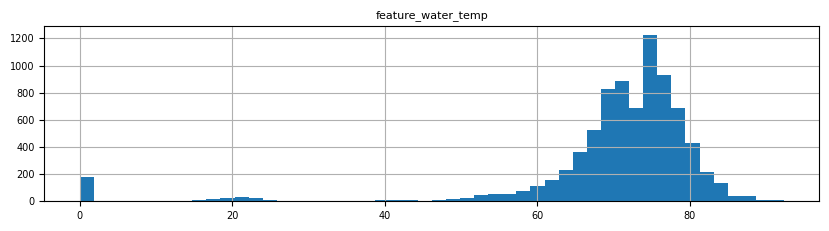

In [166]:
# Plot histograms of the numerical columns in the data

use_log_values = False

histo_cols = ["feature_water_temp"]

plot_df =  vct_bloom_df[histo_cols].apply(pd.to_numeric, errors="coerce")

# Compute logs if needed
if use_log_values:
    safe_plot_df = plot_df.where(plot_df > -1)
    safe_plot_df = np.log10(safe_plot_df + 1)
else:
    safe_plot_df = plot_df.copy()

# drop columns that are all nulls or NaN values
safe_plot_df = safe_plot_df.dropna(axis=1, how="all")

axes = safe_plot_df.hist(bins=50, figsize=(10, 5), layout=(2, 1))

for ax in axes.flatten():
    title = ax.get_title()
    wrapped_title = "\n".join(textwrap.wrap(title, width=20))
    ax.set_title(wrapped_title, fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=7)

plt.subplots_adjust(hspace=0.2, wspace=0.2)

plt.show()


In [167]:
vct_bloom_df.columns

Index(['report_date', 'waterbody', 'region', 'site', 'station', 'latitude',
       'longitude', 'cyanotaxa', 'feature_water_temp', 'feature_water_surface',
       'feature_anabaena', 'feature_aphanizomenon', 'feature_microcystin',
       'feature_oscillatoria', 'target_bloom_intensity', 'target_bloom',
       'target_bloom_intensity_sum'],
      dtype='object')

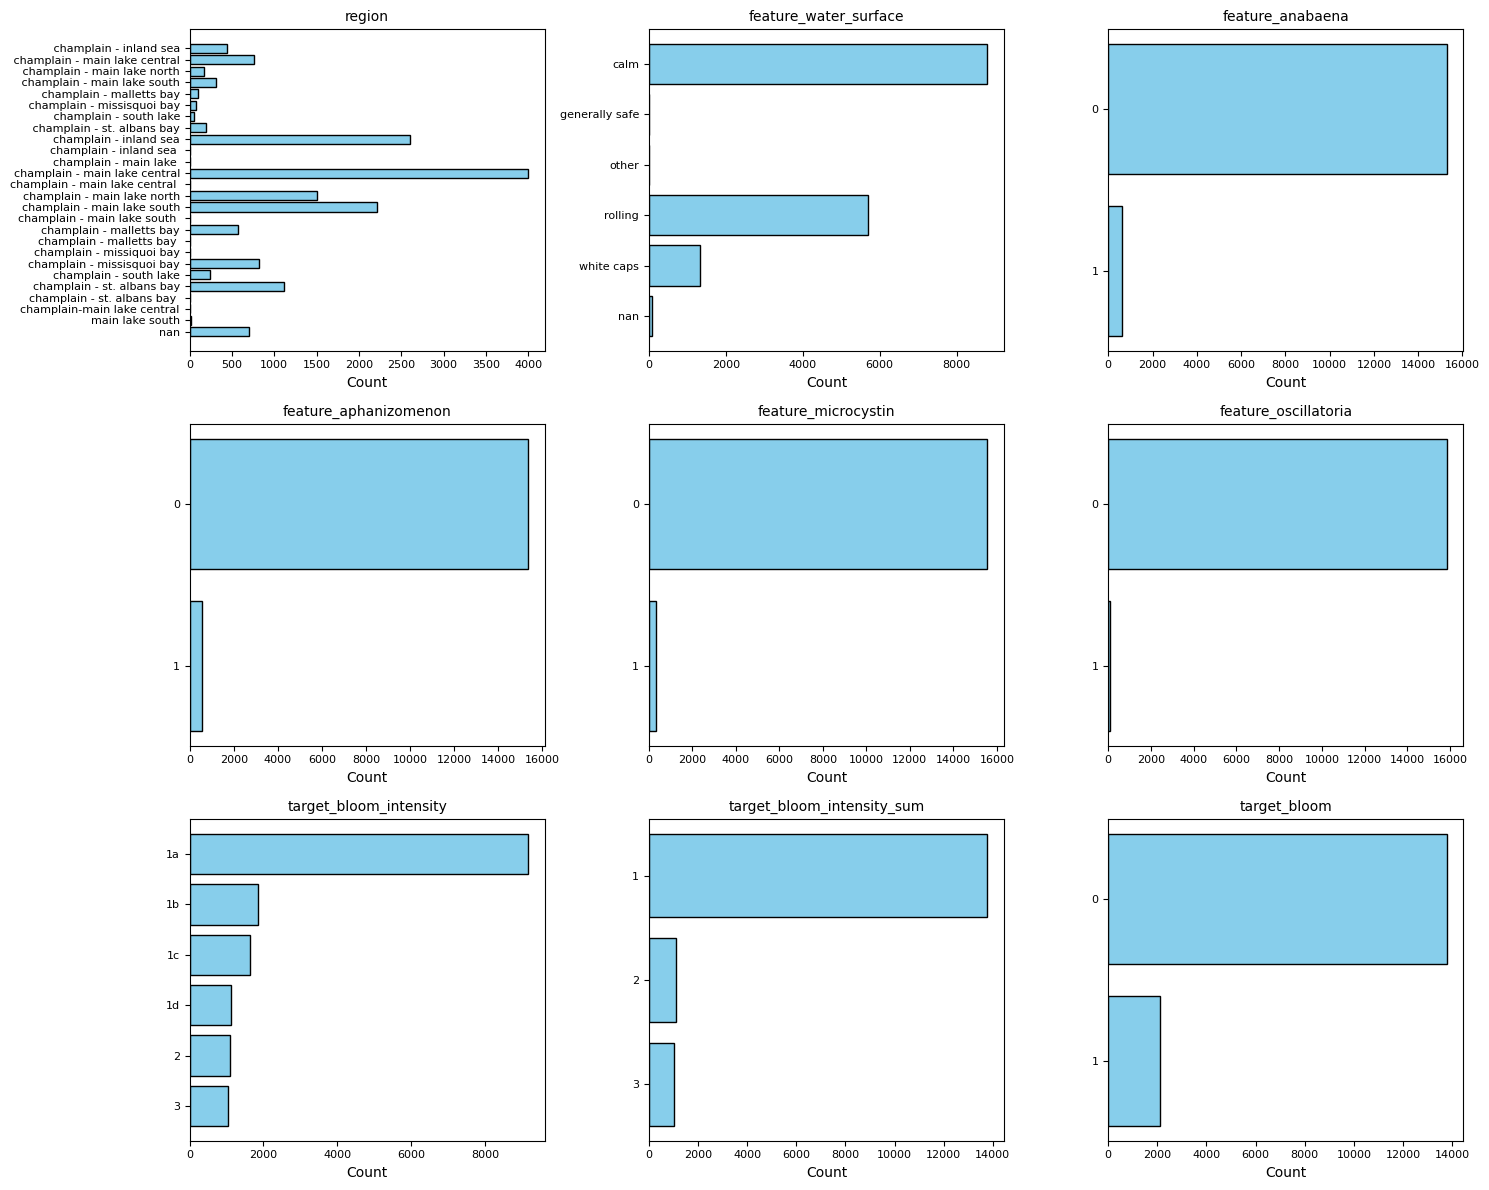

In [168]:
# plot bar charts for all the categorical columns

cat_cols = ["region", 
            "feature_water_surface",
            "feature_anabaena",
            "feature_aphanizomenon",
            "feature_microcystin",
            "feature_oscillatoria",
            "target_bloom_intensity",
            "target_bloom_intensity_sum",
            "target_bloom"
]

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()  

for i, col in enumerate(cat_cols):
    counts = vct_bloom_df[col].value_counts(dropna=False).sort_index() 
    axes[i].barh(counts.index.astype(str), counts.values, color="skyblue", edgecolor="black")
    
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("") 
    axes[i].tick_params(axis="y", labelsize=8)
    axes[i].tick_params(axis="x", labelsize=8)

    axes[i].invert_yaxis()

# Remove any empty subplots if number of columns isn't a multiple of 3
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [169]:
# Find number of values for columns with tons of values

big_cols = ["site", "station", "cyanotaxa"]

for big_col in big_cols:
    print(f"Number of unique values in {big_col}: {vct_bloom_df[big_col].nunique()}")

Number of unique values in site: 260
Number of unique values in station: 800
Number of unique values in cyanotaxa: 265


In [170]:
# Format the data for time plots

vct_bloom_df["report_date"] = pd.to_datetime(vct_bloom_df["report_date"])
vct_bloom_df["year"] = vct_bloom_df["report_date"].dt.year

# vct_bloom_mainlake_df = vct_bloom_df[vct_bloom_df["region"] == "champlain - main lake central"]

# Count records per date per year
date_counts = (
    vct_bloom_df
    .groupby(["year", "report_date"])
    .size()
    .reset_index(name="count")
)

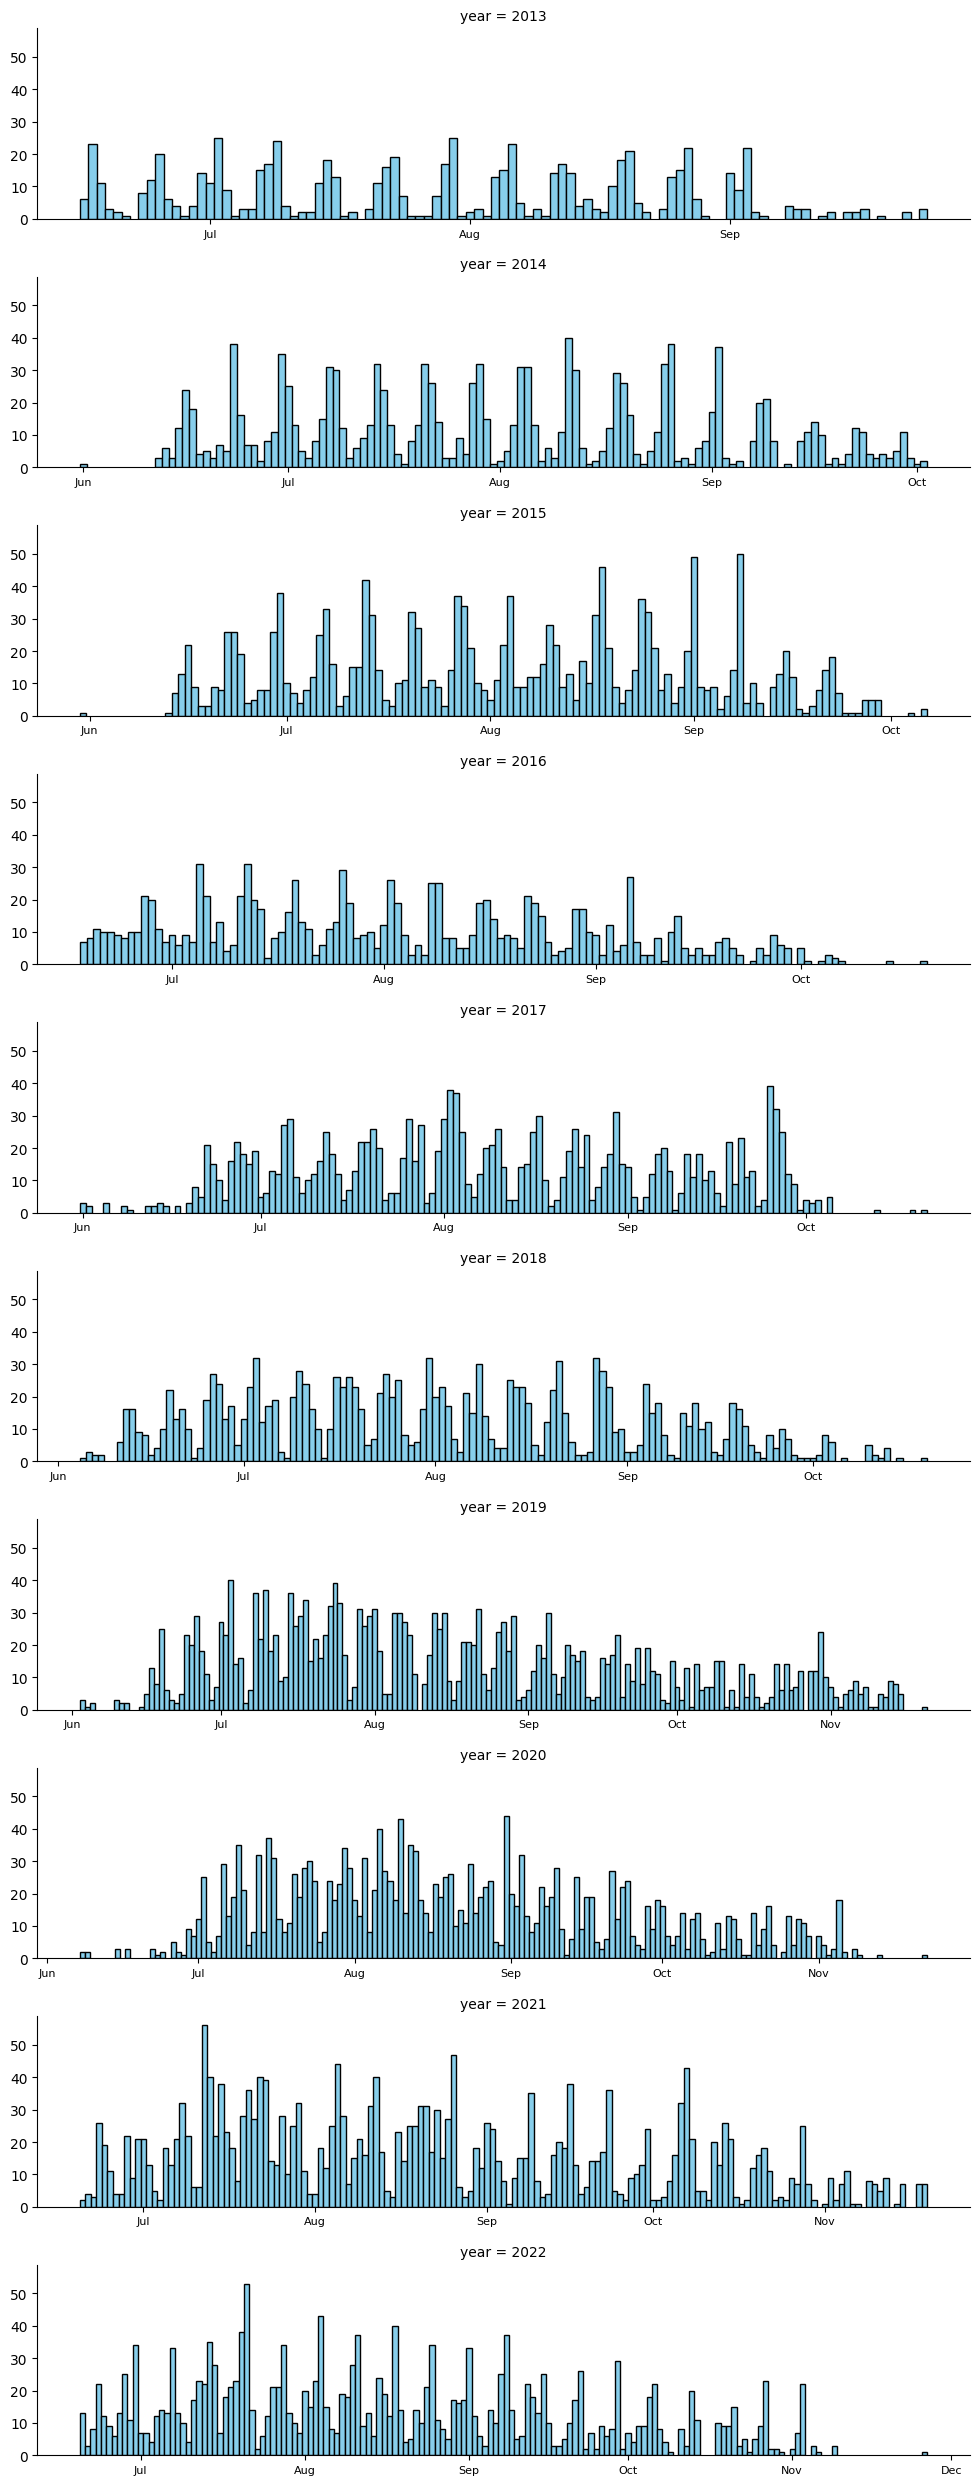

In [171]:
# Time plot - bar graphs per year

def barplot_datetime(data, **kwargs):
    ax = plt.gca()
    ax.bar(
        data["report_date"],
        data["count"],
        color="skyblue",
        edgecolor="black",
        width=1
    )

g = sns.FacetGrid(
    date_counts,
    row="year",
    height=2.5,
    aspect=4,
    sharex=False
)

g.map_dataframe(barplot_datetime)

for ax in g.axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")


In [172]:
# Compute correlation coefficients for every number variable

corr_cols = ["feature_water_temp", "feature_anabaena", "feature_aphanizomenon",
             "feature_microcystin", "feature_oscillatoria"]

corr_matrix = vct_bloom_df[corr_cols].corr()

for corr_col in corr_cols:
    print(corr_matrix[corr_col].sort_values(ascending=False).round(2), "\n")


feature_water_temp       1.00
feature_anabaena         0.05
feature_oscillatoria     0.02
feature_aphanizomenon   -0.12
feature_microcystin     -0.13
Name: feature_water_temp, dtype: float64 

feature_anabaena         1.00
feature_aphanizomenon    0.56
feature_microcystin      0.43
feature_oscillatoria     0.15
feature_water_temp       0.05
Name: feature_anabaena, dtype: float64 

feature_aphanizomenon    1.00
feature_anabaena         0.56
feature_microcystin      0.50
feature_oscillatoria     0.12
feature_water_temp      -0.12
Name: feature_aphanizomenon, dtype: float64 

feature_microcystin      1.00
feature_aphanizomenon    0.50
feature_anabaena         0.43
feature_oscillatoria     0.11
feature_water_temp      -0.13
Name: feature_microcystin, dtype: float64 

feature_oscillatoria     1.00
feature_anabaena         0.15
feature_aphanizomenon    0.12
feature_microcystin      0.11
feature_water_temp       0.02
Name: feature_oscillatoria, dtype: float64 



C:\Users\hefla\AppData\Local\Temp\ipykernel_29744\3838340879.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = plot_df.groupby("temp_bin")[y_cols].sum().reset_index()


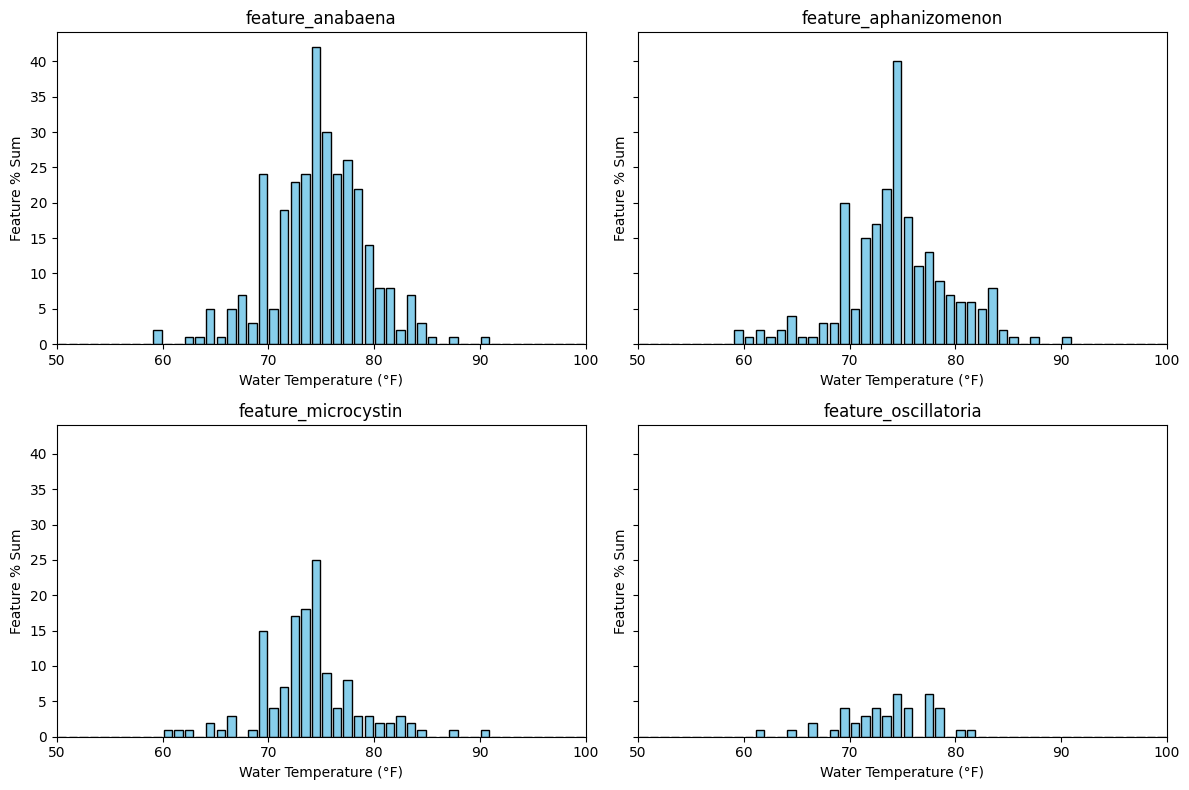

In [173]:
# Columns to plot
y_cols = ["feature_anabaena", "feature_aphanizomenon",
          "feature_microcystin", "feature_oscillatoria"]

# Ensure numeric
plot_df = vct_bloom_df[["feature_water_temp"] + y_cols].apply(pd.to_numeric, errors="coerce")

# Filter for temperature range 50–100
plot_df = plot_df[(plot_df["feature_water_temp"] >= 50) & (plot_df["feature_water_temp"] <= 100)]

# Bin the temperature finely (1-degree bins)
bin_width = 1
bins = np.arange(50, 101, bin_width)
plot_df["temp_bin"] = pd.cut(plot_df["feature_water_temp"], bins=bins, include_lowest=True)

# Aggregate: sum per temperature bin (or use mean)
agg_df = plot_df.groupby("temp_bin")[y_cols].sum().reset_index()

# Convert bin to midpoint for continuous x-axis
agg_df["temp_mid"] = agg_df["temp_bin"].apply(lambda x: x.left + bin_width/2)

# Find max value across all features for consistent y-axis
y_max = agg_df[y_cols].max().max()

# Plot each feature as a bar with shared y-axis
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, y_cols):
    ax.bar(agg_df["temp_mid"], agg_df[col], width=bin_width*0.8, color="skyblue", edgecolor="black")
    ax.set_xlim(50, 100)
    ax.set_ylim(0, y_max*1.05)  # small buffer above max
    ax.set_xlabel("Water Temperature (°F)")
    ax.set_ylabel("Feature % Sum")
    ax.set_title(col)

plt.tight_layout()
plt.show()

C:\Users\hefla\AppData\Local\Temp\ipykernel_29744\1260556692.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  feature_sum_per_bin = plot_df.groupby(pd.cut(plot_df["feature_water_temp"], bins=bins))[col].sum().values


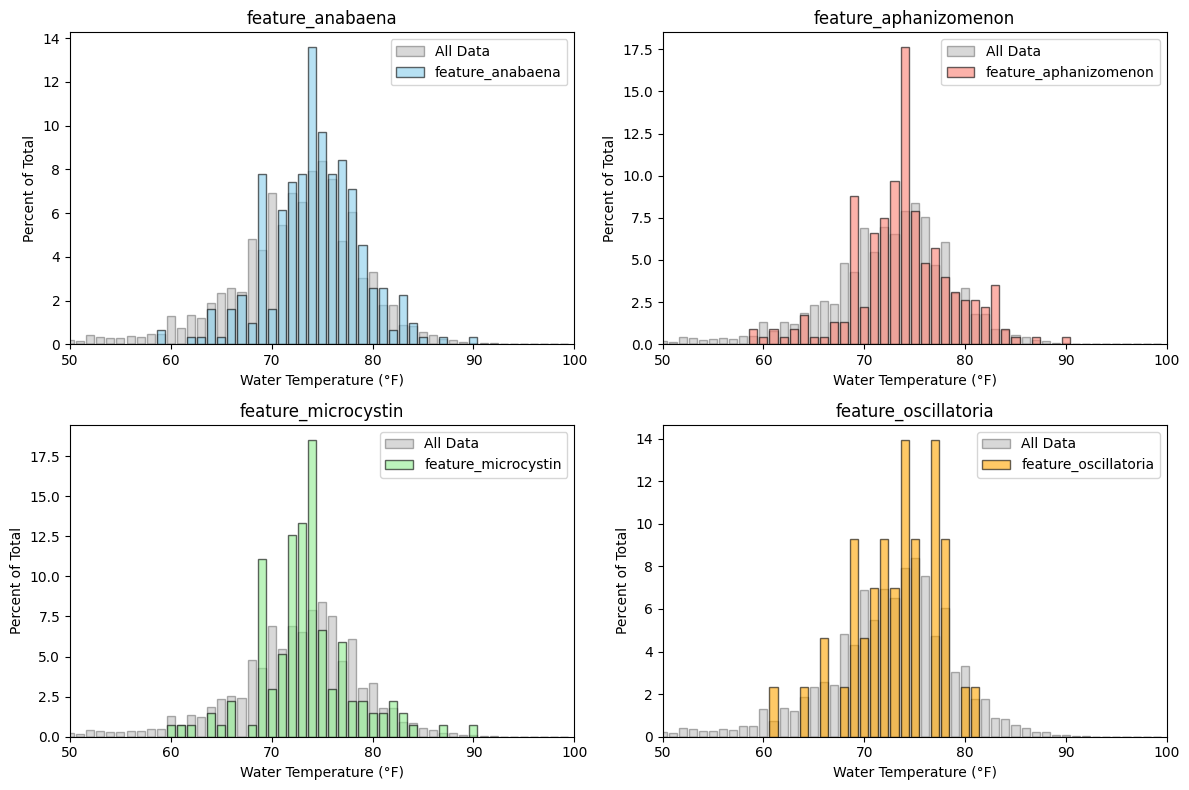

In [176]:
# Columns to plot
y_cols = ["feature_anabaena", "feature_aphanizomenon",
          "feature_microcystin", "feature_oscillatoria"]

# Ensure numeric
plot_df = vct_bloom_df[["feature_water_temp"] + y_cols].apply(pd.to_numeric, errors="coerce")

# Filter for temperature range 50–100
plot_df = plot_df[(plot_df["feature_water_temp"] >= 50) & (plot_df["feature_water_temp"] <= 100)]

# Define 1-degree bins
bins = np.arange(50, 101, 1)
bin_width = 1

# Overall data percentage per bin
hist_all_counts, _ = np.histogram(plot_df["feature_water_temp"], bins=bins)
hist_all_percent = hist_all_counts / hist_all_counts.sum() * 100

# Features: sum per bin, converted to % of total feature sum
hist_features_percent = {}
for col in y_cols:
    feature_sum_per_bin = plot_df.groupby(pd.cut(plot_df["feature_water_temp"], bins=bins))[col].sum().values
    total = feature_sum_per_bin.sum()
    hist_features_percent[col] = feature_sum_per_bin / total * 100 if total > 0 else np.zeros_like(feature_sum_per_bin)

# Create subplots: one for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = ["skyblue", "salmon", "lightgreen", "orange"]

for ax, col, color in zip(axes, y_cols, colors):
    # Plot overall data in gray
    ax.bar(bins[:-1], hist_all_percent, width=0.8, alpha=0.3, label="All Data", color="gray", edgecolor="black")
    # Plot feature
    ax.bar(bins[:-1], hist_features_percent[col], width=0.8, alpha=0.6, label=col, color=color, edgecolor="black")
    
    ax.set_xlim(50, 100)
    ax.set_xlabel("Water Temperature (°F)")
    ax.set_ylabel("Percent of Total")
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()